# 01a Traffic HSV Mask Sweep v1

이 노트북은 01에서 본 색공간 분포를 바탕으로, **HSV만 사용해서 traffic red/green mask 후보를 원본 이미지 전체에 직접 씌워보는 sandbox**다.

중요한 제한:

- ROI 적용 안 함
- contour 적용 안 함
- morphology(open/close, erode/dilate) 적용 안 함
- temporal voting 적용 안 함
- contract 확정 안 함

즉, 이번 단계의 질문은 하나다.

> HSV 색 조건만으로 신호등 불빛이 어느 정도 분리되는가?

이걸 봐야 다음에 contour/ROI가 어떤 문제를 해결해야 하는지 분명해진다.

## 왜 원본 전체 이미지에 mask를 씌우나?

ROI를 먼저 걸면 false positive가 사라져 보일 수 있다. 그러면 색 조건 자체가 좋은지, ROI 덕분에 좋아 보이는지 구분이 안 된다.

그래서 이번 01a에서는 일부러 원본 전체 이미지에 mask를 씌운다.

우리가 보고 싶은 것은 다음이다.

1. 신호등 불빛이 잡히는가?
2. 노란 차선이 같이 잡히는가?
3. 천장 조명, 벽 반사, 초록 바닥이 같이 잡히는가?
4. red mask가 green 이미지에서 얼마나 튀는가?
5. green mask가 red 이미지에서 얼마나 튀는가?

이 단계에서 false positive가 생기는 건 실패가 아니라 정보다. 이후 contour와 ROI가 정확히 뭘 줄여야 하는지 알려주기 때문이다.

In [1]:
from pathlib import Path
import os
import random
import math
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

EXPERIMENT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector")
DATASET_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset")
TRAFFIC_RAW = DATASET_ROOT / "traffic" / "raw"
RUN_NAME = "01a_traffic_hsv_mask_sweep_v1"
OUT_DIR = EXPERIMENT_ROOT / "review_outputs" / RUN_NAME
TABLE_DIR = OUT_DIR / "tables"
OVERLAY_DIR = OUT_DIR / "overlays"
NOTE_DIR = OUT_DIR / "notes"

for d in [TABLE_DIR, OVERLAY_DIR, NOTE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 18
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("TRAFFIC_RAW:", TRAFFIC_RAW, "exists=", TRAFFIC_RAW.exists())
print("OUT_DIR:", OUT_DIR)

TRAFFIC_RAW: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\traffic\raw exists= True
OUT_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1


## 경로 / 이미지 helper

Windows 긴 경로와 한글 경로에서 `cv2.imread`가 실패할 수 있어서, 12번/18번 00/01과 같은 방식으로 이미지를 읽고 쓴다.

또한 이미지 출력은 파일 경로가 아니라 bytes를 노트북 output에 embed한다. 이렇게 해야 VSCode/Jupyter 프론트엔드에서 긴 경로 문제 없이 바로 보인다.

In [2]:
def fs_path(path):
    path = Path(path)
    s = str(path.resolve())
    if os.name == "nt" and not s.startswith("\\\\?\\"):
        return "\\\\?\\" + s
    return s


def exists_fs(path):
    return Path(fs_path(path)).exists()


def imread_bgr(path):
    data = np.fromfile(fs_path(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f"Failed to read image: {path}")
    return img


def imwrite_bgr(path, img, quality=95):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix.lower()
    params = []
    if ext in {".jpg", ".jpeg"}:
        params = [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)]
    ok, buf = cv2.imencode(ext, img, params)
    if not ok:
        raise RuntimeError(f"Failed to encode image: {path}")
    buf.tofile(fs_path(path))


def read_binary_fs(path):
    with open(fs_path(path), "rb") as f:
        return f.read()


def show_saved_image(path, width=1100):
    path = Path(path)
    fmt = "png" if path.suffix.lower() == ".png" else "jpeg"
    display(Image(data=read_binary_fs(path), format=fmt, width=width))


def draw_label(img, text, org=(8, 24), scale=0.62, color=(255,255,255), thickness=2):
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale, (0,0,0), thickness+2, cv2.LINE_AA)
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness, cv2.LINE_AA)
    return img

## 데이터 index와 샘플 선택

이번 노트북은 traffic 데이터만 사용한다.

시각화는 너무 길어지지 않도록 label당 일부 샘플만 사용한다. 하지만 mask ratio 통계는 샘플 수를 별도로 늘릴 수 있게 분리했다.

- `VIS_SAMPLES_PER_LABEL`: overlay로 볼 이미지 수
- `STAT_SAMPLES_PER_LABEL`: mask pixel ratio를 계산할 이미지 수

둘 다 필요하면 사용자가 직접 값을 바꿔 재실행할 수 있다.

In [3]:
def iter_images(root):
    root = Path(root)
    if not exists_fs(root):
        return []
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

records = []
for p in iter_images(TRAFFIC_RAW):
    label = p.parent.name.lower()
    if label in {"red", "green"}:
        records.append({
            "label": label,
            "path": str(p),
            "filename": p.name,
            "rel_path": str(p.relative_to(DATASET_ROOT)),
        })

traffic_df = pd.DataFrame(records)
traffic_df.to_csv(TABLE_DIR / "traffic_dataset_index.csv", index=False, encoding="utf-8-sig")
print(traffic_df.groupby("label").size())
display(traffic_df.head())
assert set(traffic_df["label"].unique()) == {"red", "green"}

VIS_SAMPLES_PER_LABEL = 8
STAT_SAMPLES_PER_LABEL = 80

vis_records = []
stat_records = []
for label, sub in traffic_df.groupby("label"):
    vis_records.extend(sub.sample(n=min(VIS_SAMPLES_PER_LABEL, len(sub)), random_state=RANDOM_SEED).to_dict("records"))
    stat_records.extend(sub.sample(n=min(STAT_SAMPLES_PER_LABEL, len(sub)), random_state=RANDOM_SEED + 1).to_dict("records"))

vis_df = pd.DataFrame(vis_records)
stat_df = pd.DataFrame(stat_records)
vis_df.to_csv(TABLE_DIR / "traffic_hsv_sweep_visual_sample_records.csv", index=False, encoding="utf-8-sig")
stat_df.to_csv(TABLE_DIR / "traffic_hsv_sweep_stat_sample_records.csv", index=False, encoding="utf-8-sig")
print("visual samples")
print(vis_df.groupby("label").size())
print("stat samples")
print(stat_df.groupby("label").size())

label
green    313
red      343
dtype: int64


,label,path,filename,rel_path
0,green,~\02_Projects\University\26-1_Em...,20260430_174909_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174909_signs_green_...
1,green,~\02_Projects\University\26-1_Em...,20260430_174909_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174909_signs_green_...
2,green,~\02_Projects\University\26-1_Em...,20260430_174909_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174909_signs_green_...
3,green,~\02_Projects\University\26-1_Em...,20260430_174909_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174909_signs_green_...
4,green,~\02_Projects\University\26-1_Em...,20260430_174910_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174910_signs_green_...


visual samples
label
green    8
red      8
dtype: int64
stat samples
label
green    80
red      80
dtype: int64


## HSV 후보 sweep 값

01에서 본 대략적인 분포는 다음과 같았다.

- green 신호: `H ≈ 70~90`
- red 신호: `H ≈ 0~10` 또는 `H ≈ 170~179`
- yellow lane / yellow light: `H ≈ 30~35`

이번 sweep은 이 관찰을 바탕으로 한다. 단, 아래 값은 최종값이 아니라 **눈으로 비교하기 위한 후보군**이다.

조절 가능한 값:

- `h_ranges`: Hue 범위. red는 wrap-around 때문에 두 구간을 쓴다.
- `s_min`: saturation 최소값. 높일수록 회색/흰 반사광이 줄지만, 어두운 신호를 놓칠 수 있다.
- `v_min`: brightness 최소값. 높일수록 어두운 잡음이 줄지만, 어두운 신호를 놓칠 수 있다.

In [4]:
GREEN_CANDIDATES = [
    {"name": "green_wide_s120_v120", "target": "green", "h_ranges": [(60, 100)], "s_min": 120, "v_min": 120},
    {"name": "green_core_s140_v140", "target": "green", "h_ranges": [(65, 95)], "s_min": 140, "v_min": 140},
    {"name": "green_core_s160_v150", "target": "green", "h_ranges": [(65, 95)], "s_min": 160, "v_min": 150},
    {"name": "green_tight_s170_v160", "target": "green", "h_ranges": [(70, 92)], "s_min": 170, "v_min": 160},
]

RED_CANDIDATES = [
    {"name": "red_wide_s120_v120", "target": "red", "h_ranges": [(0, 12), (168, 179)], "s_min": 120, "v_min": 120},
    {"name": "red_core_s140_v140", "target": "red", "h_ranges": [(0, 10), (170, 179)], "s_min": 140, "v_min": 140},
    {"name": "red_core_s160_v150", "target": "red", "h_ranges": [(0, 10), (172, 179)], "s_min": 160, "v_min": 150},
    {"name": "red_tight_s180_v160", "target": "red", "h_ranges": [(0, 8), (174, 179)], "s_min": 180, "v_min": 160},
]

ALL_CANDIDATES = GREEN_CANDIDATES + RED_CANDIDATES
candidate_df = pd.DataFrame([
    {**c, "h_ranges": str(c["h_ranges"])} for c in ALL_CANDIDATES
])
candidate_df.to_csv(TABLE_DIR / "traffic_hsv_sweep_candidates.csv", index=False, encoding="utf-8-sig")
display(candidate_df)

,name,target,h_ranges,s_min,v_min
0,green_wide_s120_v120,green,"[(60, 100)]",120,120
1,green_core_s140_v140,green,"[(65, 95)]",140,140
2,green_core_s160_v150,green,"[(65, 95)]",160,150
3,green_tight_s170_v160,green,"[(70, 92)]",170,160
4,red_wide_s120_v120,red,"[(0, 12), (168, 179)]",120,120
5,red_core_s140_v140,red,"[(0, 10), (170, 179)]",140,140
6,red_core_s160_v150,red,"[(0, 10), (172, 179)]",160,150
7,red_tight_s180_v160,red,"[(0, 8), (174, 179)]",180,160


## HSV mask 함수

mask는 원본 전체 이미지에서 계산한다.

red의 경우 Hue가 `0`과 `179` 양끝으로 갈라질 수 있으므로 `h_ranges`를 여러 개 받을 수 있게 했다.

이 함수는 색 mask만 만든다. contour도 morphology도 ROI도 없다.

In [5]:
def hsv_mask_from_candidate(bgr, cand):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]
    h_mask = np.zeros(h.shape, dtype=bool)
    for lo, hi in cand["h_ranges"]:
        h_mask |= (h >= int(lo)) & (h <= int(hi))
    mask = h_mask & (s >= int(cand["s_min"])) & (v >= int(cand["v_min"]))
    return (mask.astype(np.uint8) * 255)


def overlay_mask(bgr, mask, color_bgr, alpha=0.55):
    out = bgr.copy()
    idx = mask > 0
    if not np.any(idx):
        return out
    color = np.array(color_bgr, dtype=np.float32).reshape(1, 3)
    base = bgr[idx].astype(np.float32)
    blended = base * (1.0 - float(alpha)) + color * float(alpha)
    out[idx] = np.clip(blended, 0, 255).astype(np.uint8)
    return out


def mask_ratio(mask):
    return float((mask > 0).mean())


def candidate_color(cand):
    if cand["target"] == "green":
        return (0, 255, 0)
    return (0, 0, 255)

## Mask ratio 요약

먼저 숫자로 대략적인 경향을 본다.

`true_mean_ratio`는 target label 이미지에서 mask가 차지하는 비율이고, `cross_mean_ratio`는 반대 label 이미지에서 mask가 차지하는 비율이다.

주의: mask ratio가 낮다고 무조건 좋은 건 아니다. 신호등 자체가 작기 때문에 좋은 detector도 mask ratio는 낮을 수 있다. 다만 cross ratio가 지나치게 높으면 색 조건이 헷갈리고 있다는 신호다.

In [6]:
ratio_rows = []
for cand in ALL_CANDIDATES:
    for rec in stat_df.to_dict("records"):
        bgr = imread_bgr(rec["path"])
        mask = hsv_mask_from_candidate(bgr, cand)
        ratio_rows.append({
            "candidate": cand["name"],
            "target": cand["target"],
            "eval_label": rec["label"],
            "filename": rec["filename"],
            "mask_ratio": mask_ratio(mask),
            "mask_pixels": int((mask > 0).sum()),
            "image_pixels": int(mask.size),
        })

ratio_df = pd.DataFrame(ratio_rows)
ratio_df.to_csv(TABLE_DIR / "traffic_hsv_sweep_mask_ratios_per_image.csv", index=False, encoding="utf-8-sig")

summary_rows = []
for cand_name, sub in ratio_df.groupby("candidate"):
    target = sub["target"].iloc[0]
    true_sub = sub[sub["eval_label"] == target]
    cross_sub = sub[sub["eval_label"] != target]
    summary_rows.append({
        "candidate": cand_name,
        "target": target,
        "true_mean_ratio": float(true_sub["mask_ratio"].mean()),
        "true_p90_ratio": float(true_sub["mask_ratio"].quantile(0.90)),
        "cross_mean_ratio": float(cross_sub["mask_ratio"].mean()),
        "cross_p90_ratio": float(cross_sub["mask_ratio"].quantile(0.90)),
        "true_over_cross_mean": float((true_sub["mask_ratio"].mean() + 1e-9) / (cross_sub["mask_ratio"].mean() + 1e-9)),
    })
summary_df = pd.DataFrame(summary_rows).sort_values(["target", "true_over_cross_mean"], ascending=[True, False])
summary_df.to_csv(TABLE_DIR / "traffic_hsv_sweep_mask_ratio_summary.csv", index=False, encoding="utf-8-sig")
display(summary_df)

,candidate,target,true_mean_ratio,true_p90_ratio,cross_mean_ratio,cross_p90_ratio,true_over_cross_mean
2,green_tight_s170_v160,green,0.001678,0.003029,0.000000,0.000000,1.677944e+06
1,green_core_s160_v150,green,0.002127,0.003638,0.000001,0.000005,1.487245e+03
0,green_core_s140_v140,green,0.002452,0.004054,0.000011,0.000029,2.275453e+02
3,green_wide_s120_v120,green,0.006074,0.018085,0.000852,0.001029,7.130085e+00
4,red_core_s140_v140,red,0.000388,0.000948,0.000000,0.000000,3.877186e+05
5,red_core_s160_v150,red,0.000310,0.000738,0.000000,0.000000,3.097246e+05
6,red_tight_s180_v160,red,0.000225,0.000563,0.000000,0.000000,2.252509e+05
7,red_wide_s120_v120,red,0.000577,0.001521,0.000003,0.000011,2.278790e+02


## Overlay sheet 생성 방식

각 candidate마다 두 종류의 sheet를 만든다.

- target sheet: 예를 들어 green mask를 green 이미지에 씌운 결과
- cross sheet: 예를 들어 green mask를 red 이미지에 씌운 결과

한 이미지마다 세 칸을 보여준다.

1. original
2. binary mask
3. mask overlay

여기서 봐야 하는 것:

- target sheet에서 신호등 불빛이 잡히는가?
- cross sheet에서 반대 색 신호등이나 노란 차선이 튀는가?
- mask가 신호등보다 노란 차선/바닥/벽에서 더 많이 튀지는 않는가?

In [7]:
def make_mask_tile_triplet(bgr, mask, overlay, label_text, tile_w=300, tile_h=225):
    original = cv2.resize(bgr, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
    mask_bgr = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    mask_bgr = cv2.resize(mask_bgr, (tile_w, tile_h), interpolation=cv2.INTER_NEAREST)
    over = cv2.resize(overlay, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
    draw_label(original, "original", (8, 22), scale=0.55)
    draw_label(mask_bgr, "mask", (8, 22), scale=0.55)
    draw_label(over, "overlay", (8, 22), scale=0.55)
    row = np.concatenate([original, mask_bgr, over], axis=1)
    footer = np.zeros((34, row.shape[1], 3), dtype=np.uint8)
    draw_label(footer, label_text, (8, 23), scale=0.48)
    return np.concatenate([row, footer], axis=0)


def make_candidate_sheet(cand, records, out_path, title):
    rows = []
    color = candidate_color(cand)
    for rec in records:
        bgr = imread_bgr(rec["path"])
        mask = hsv_mask_from_candidate(bgr, cand)
        over = overlay_mask(bgr, mask, color_bgr=color, alpha=0.55)
        ratio = mask_ratio(mask)
        text = f'{rec["label"]} | ratio={ratio:.5f} | {rec["filename"][:70]}'
        rows.append(make_mask_tile_triplet(bgr, mask, over, text))
    sheet = np.concatenate(rows, axis=0)
    header = np.zeros((44, sheet.shape[1], 3), dtype=np.uint8)
    draw_label(header, title, (8, 30), scale=0.72)
    sheet = np.concatenate([header, sheet], axis=0)
    imwrite_bgr(out_path, sheet)
    return out_path

## Green mask sweep overlay

먼저 green 후보를 본다.

좋은 green 후보는 다음 조건을 만족해야 한다.

- green 이미지에서 신호등 초록 불빛이 잡힘
- red 이미지에서 빨간 불빛이나 노란 차선이 크게 잡히지 않음
- 초록 바닥이 너무 많이 잡히지 않음

아직 ROI를 안 쓰므로 초록 바닥이 조금 잡히는 건 자연스러운 문제다. 이 문제가 색만으로 심한지 확인한다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_wide_s120_v120_on_green_true.jpg


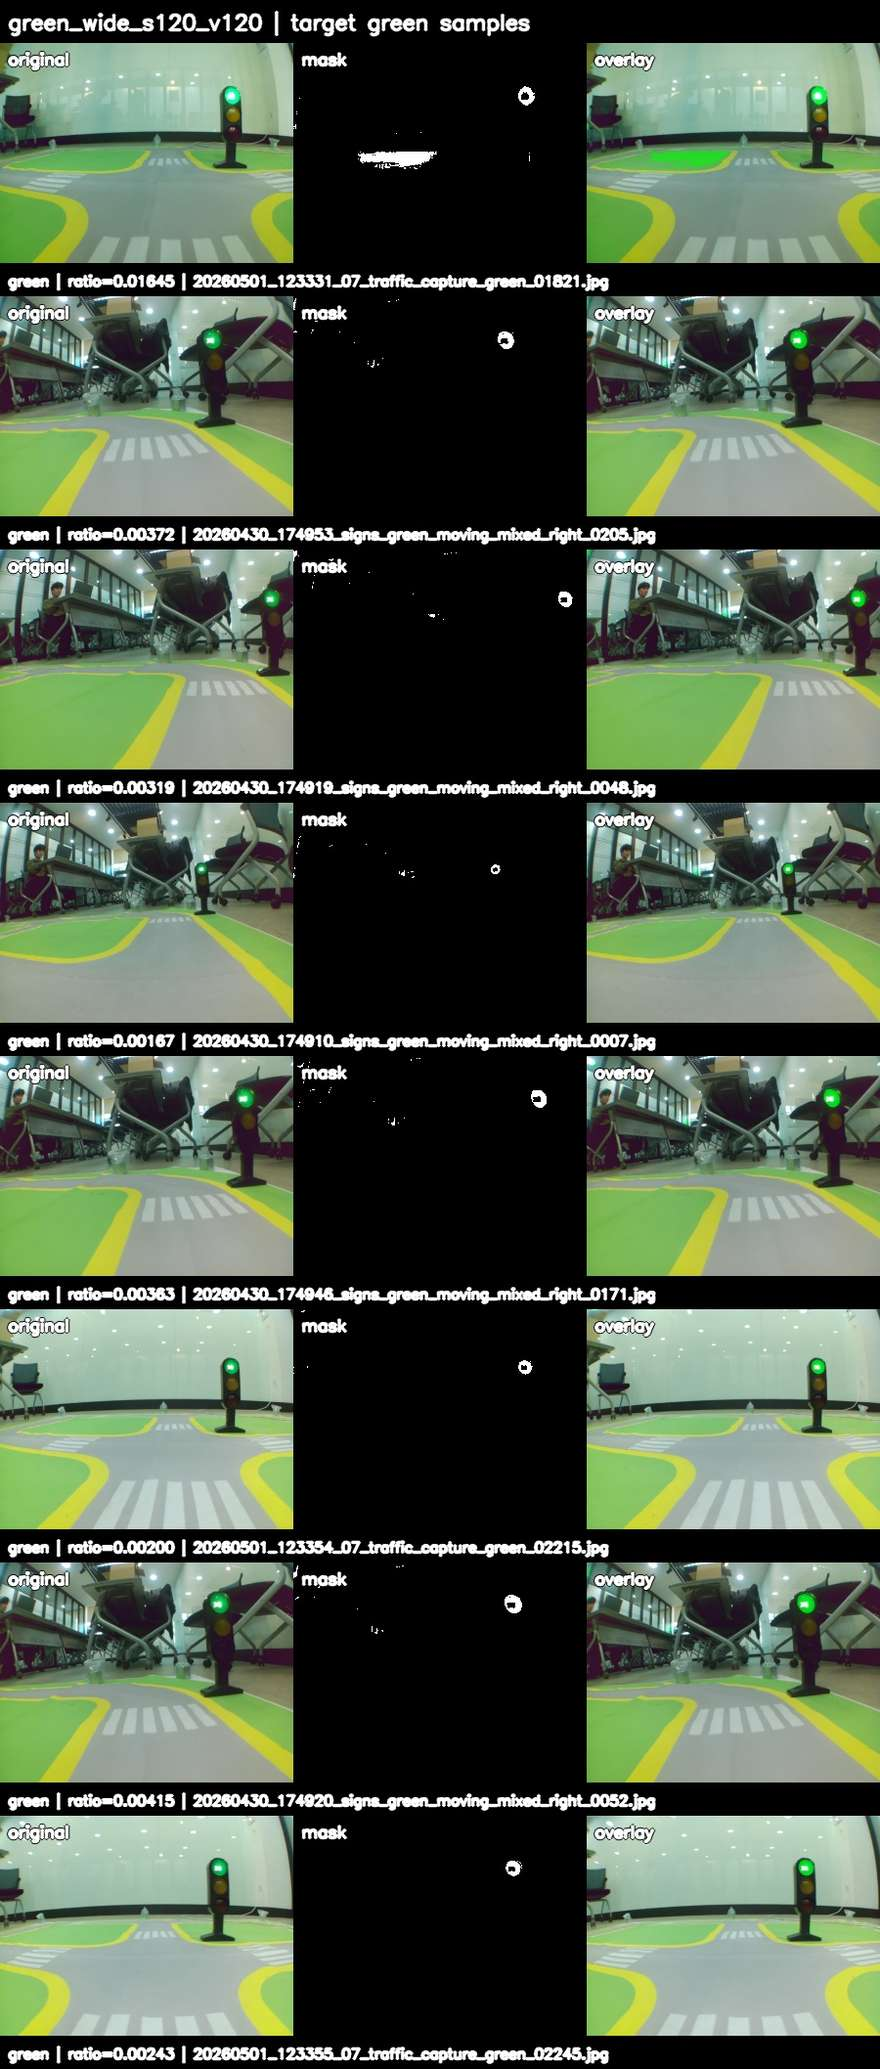

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_wide_s120_v120_on_red_cross.jpg


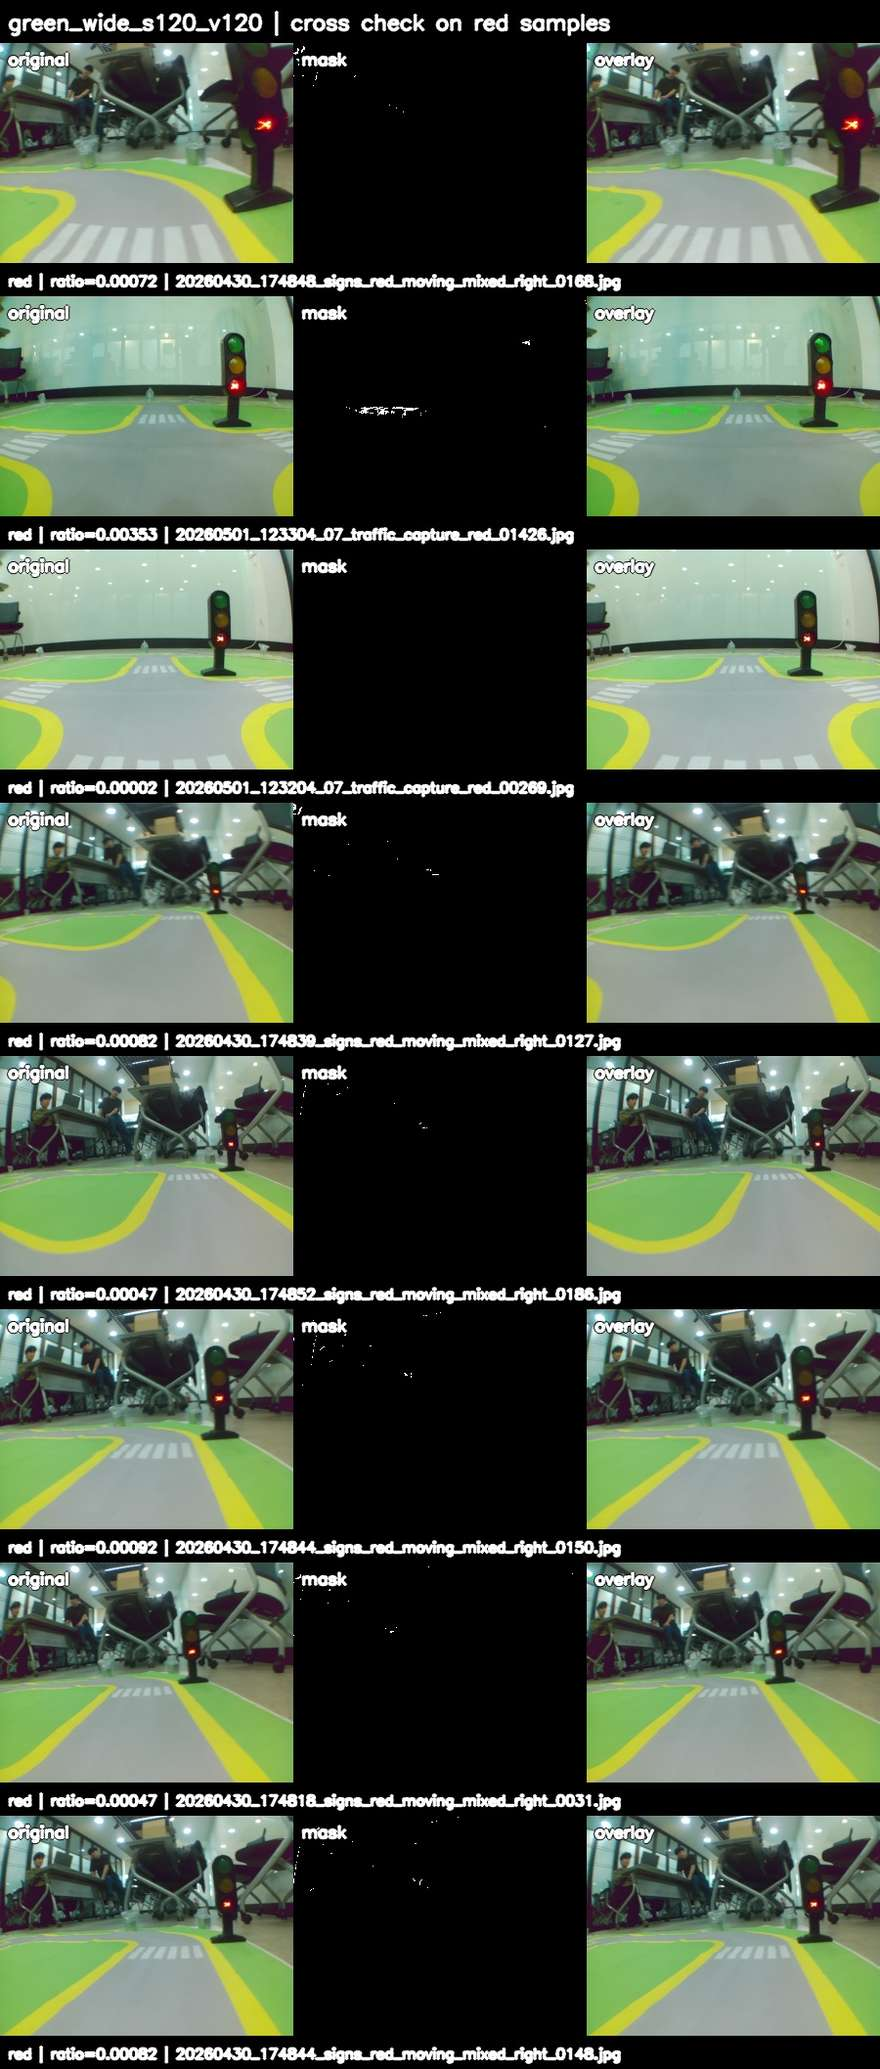

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_core_s140_v140_on_green_true.jpg


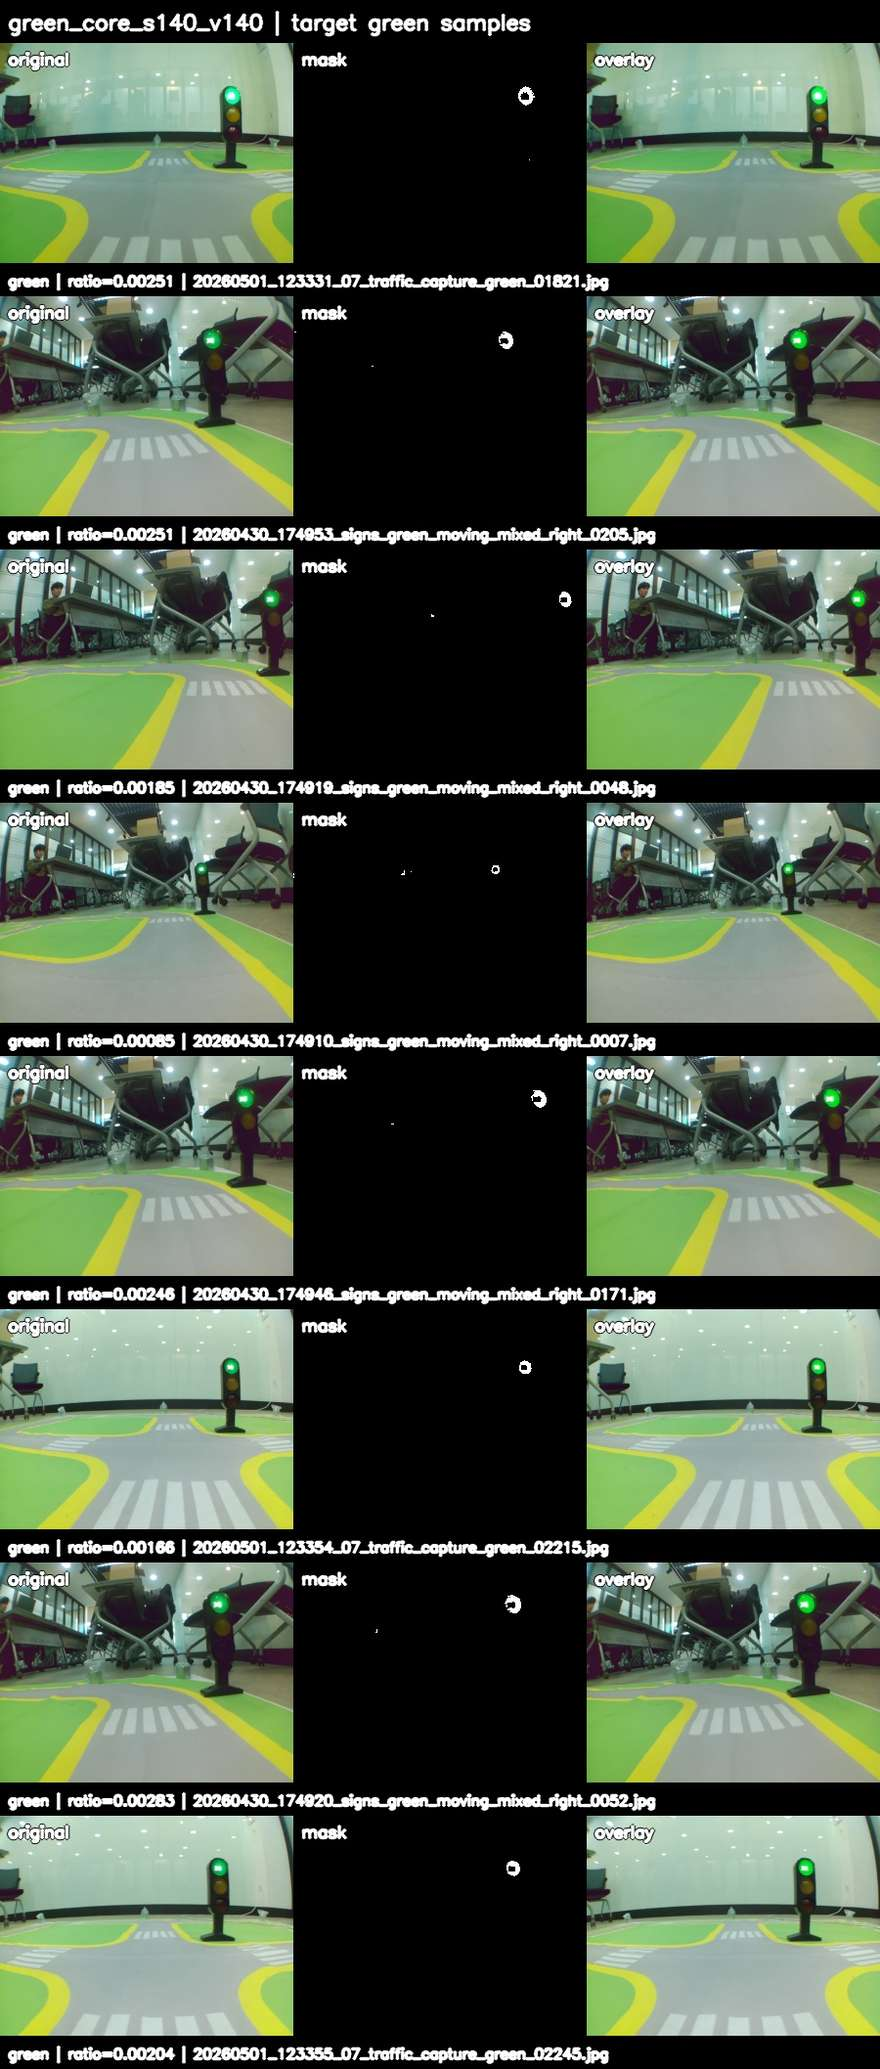

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_core_s140_v140_on_red_cross.jpg


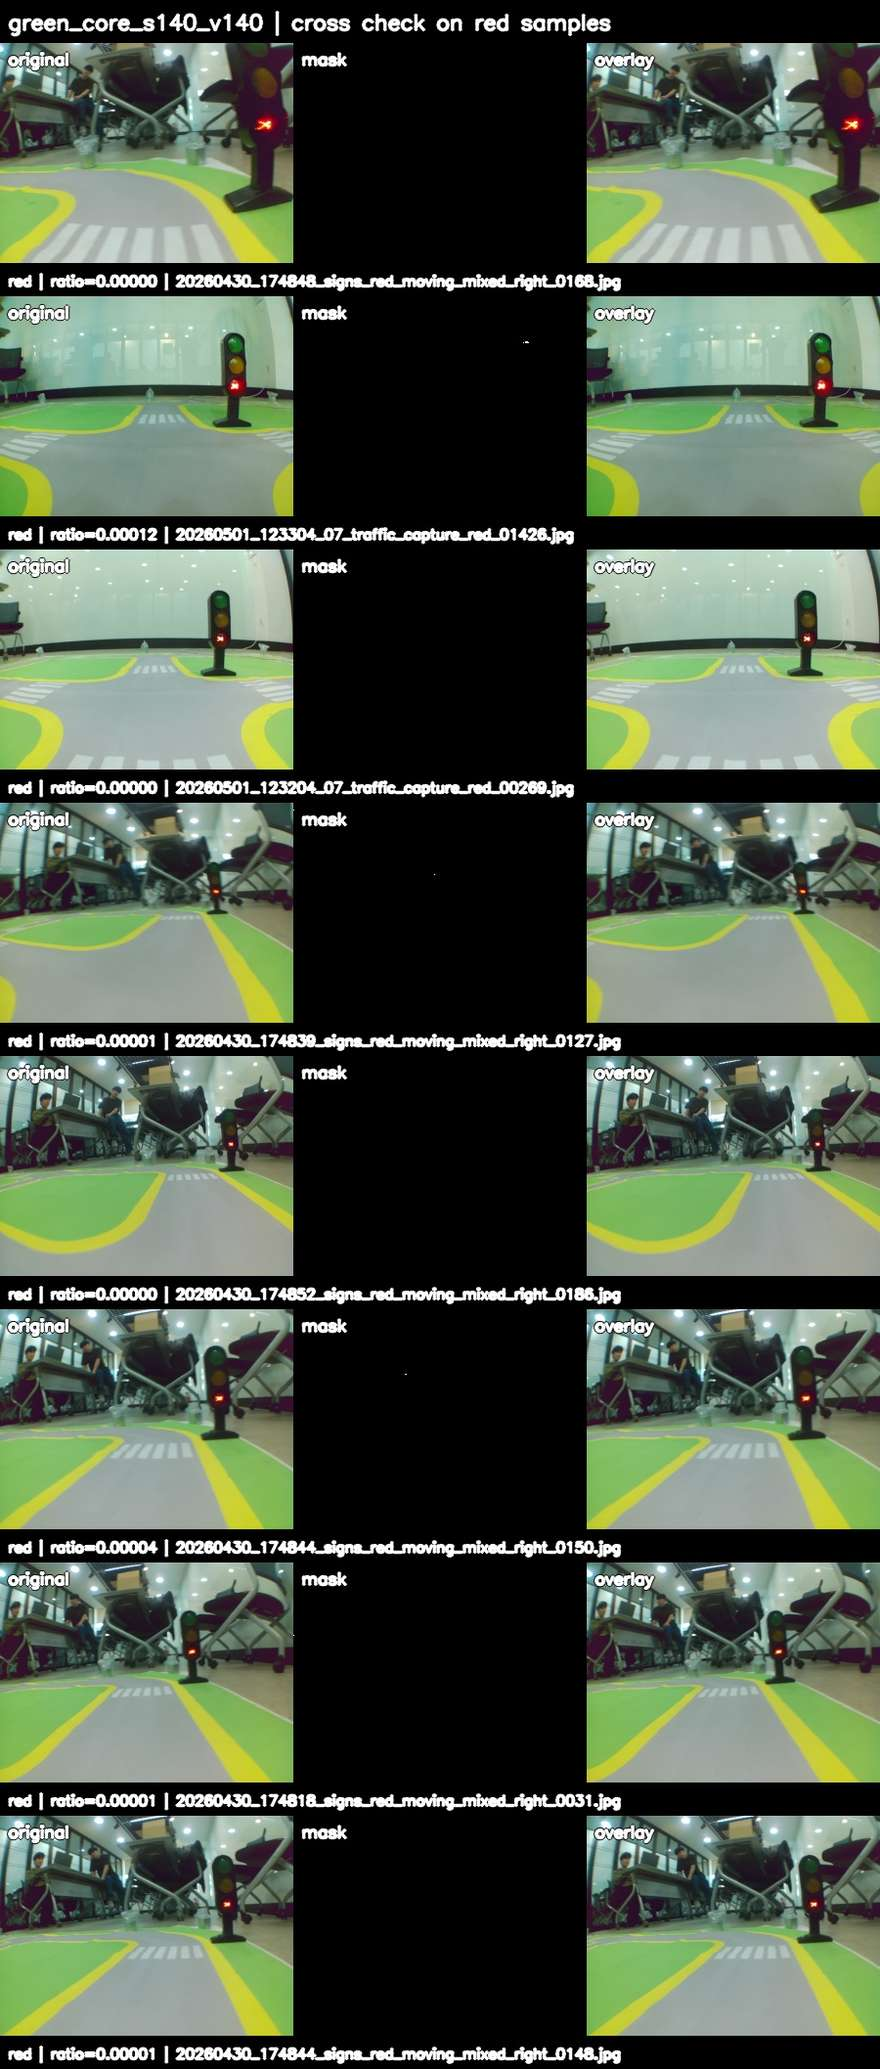

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_core_s160_v150_on_green_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_core_s160_v150_on_red_cross.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_tight_s170_v160_on_green_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\green_tight_s170_v160_on_red_cross.jpg


In [8]:
green_true_records = vis_df[vis_df["label"] == "green"].to_dict("records")
green_cross_records = vis_df[vis_df["label"] == "red"].to_dict("records")

green_sheet_paths = []
for cand in GREEN_CANDIDATES:
    out_true = OVERLAY_DIR / f'{cand["name"]}_on_green_true.jpg'
    out_cross = OVERLAY_DIR / f'{cand["name"]}_on_red_cross.jpg'
    make_candidate_sheet(cand, green_true_records, out_true, f'{cand["name"]} | target green samples')
    make_candidate_sheet(cand, green_cross_records, out_cross, f'{cand["name"]} | cross check on red samples')
    green_sheet_paths.extend([out_true, out_cross])
    print(out_true)
    show_saved_image(out_true, width=1100)
    print(out_cross)
    show_saved_image(out_cross, width=1100)

## Red mask sweep overlay

red 후보는 Hue wrap-around 때문에 두 구간을 쓴다.

좋은 red 후보는 다음 조건을 만족해야 한다.

- red 이미지에서 빨간 불빛이 잡힘
- green 이미지에서 초록 불빛이나 노란 차선이 크게 잡히지 않음
- 바닥의 빨간 final line 또는 빨간 물체가 과하게 잡히지 않음

특히 red는 나중에 redline detector와 색이 겹친다. 그래서 traffic detector에서는 최종적으로 ROI/contour가 더 중요해질 가능성이 높다. 하지만 지금은 일부러 색만 본다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_wide_s120_v120_on_red_true.jpg


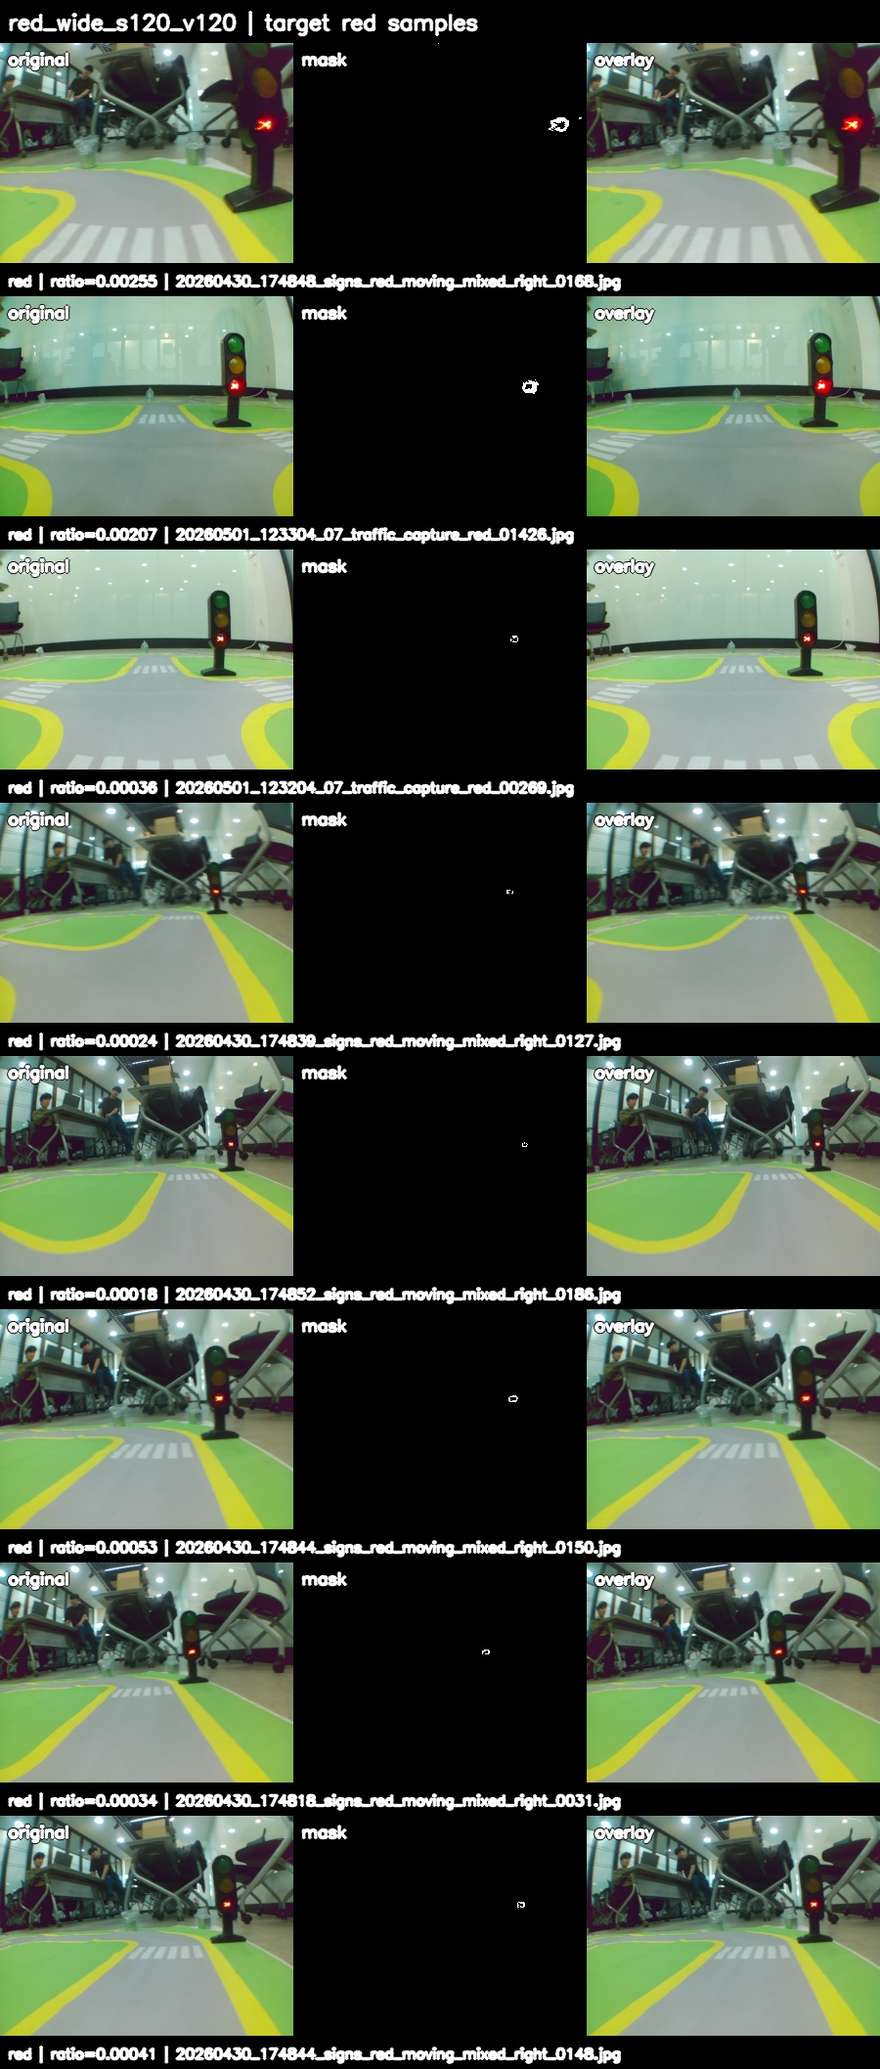

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_wide_s120_v120_on_green_cross.jpg


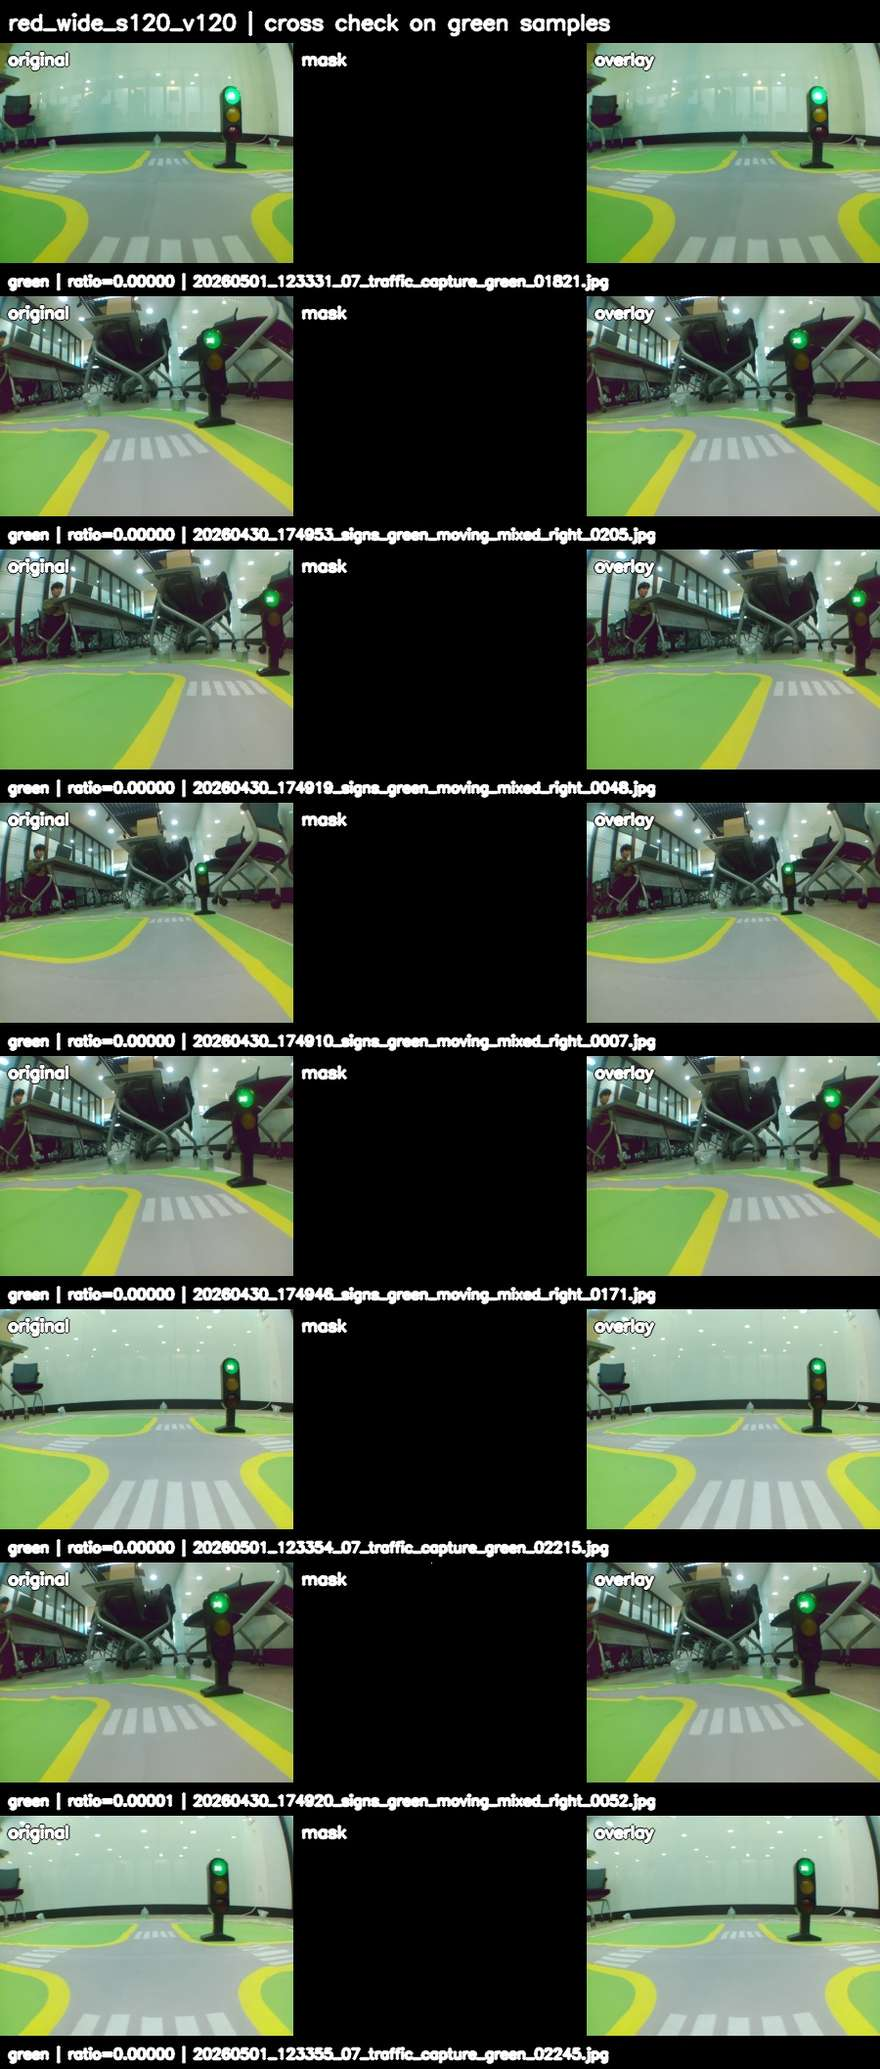

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_core_s140_v140_on_red_true.jpg


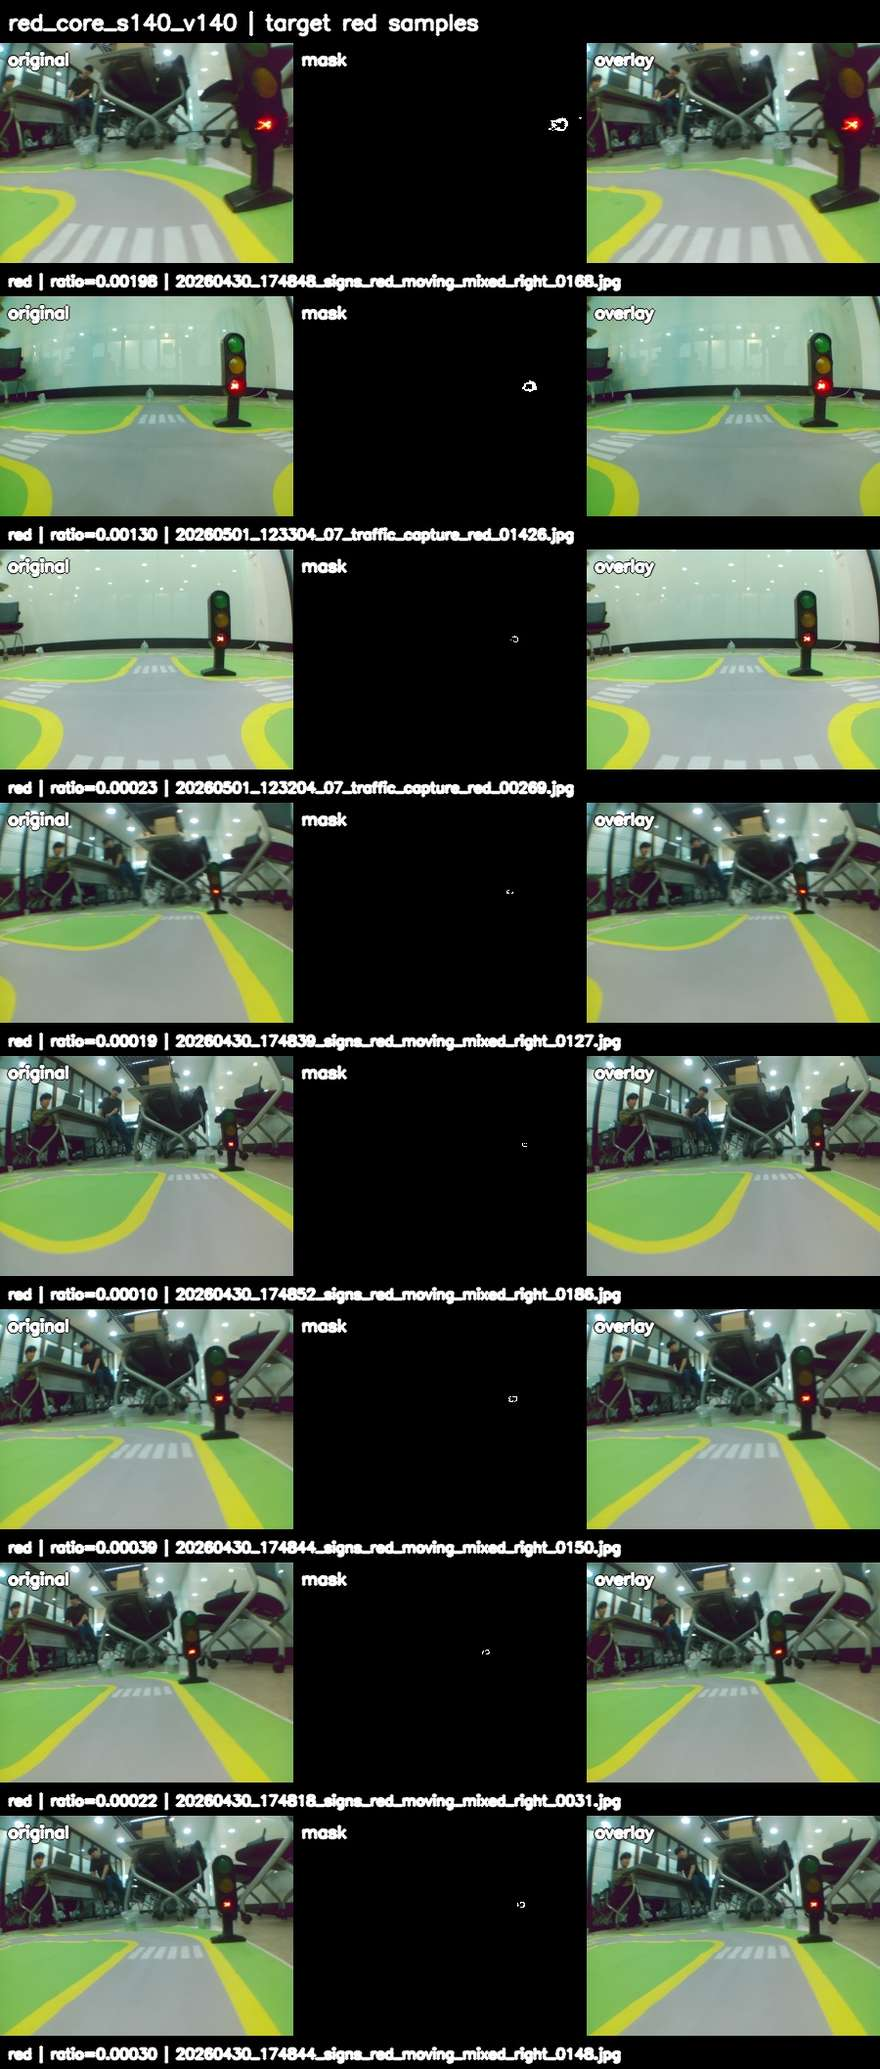

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_core_s140_v140_on_green_cross.jpg


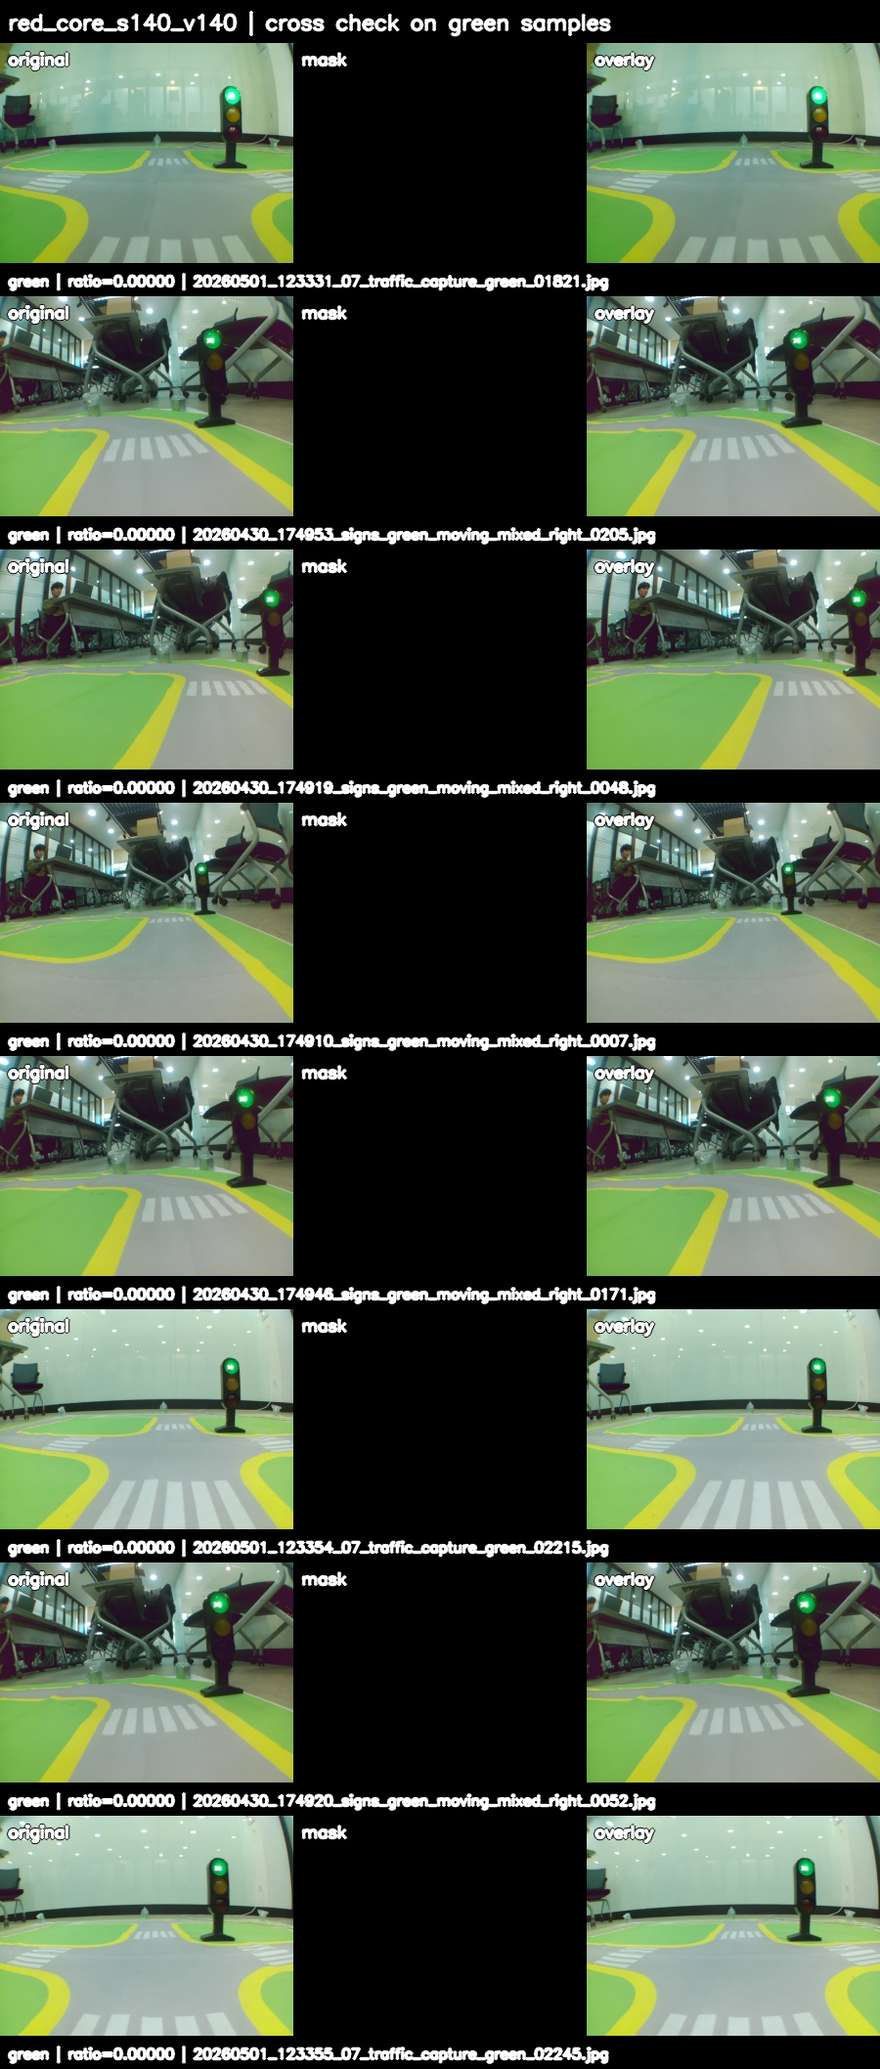

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_core_s160_v150_on_red_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_core_s160_v150_on_green_cross.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_tight_s180_v160_on_red_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\red_tight_s180_v160_on_green_cross.jpg


In [9]:
red_true_records = vis_df[vis_df["label"] == "red"].to_dict("records")
red_cross_records = vis_df[vis_df["label"] == "green"].to_dict("records")

red_sheet_paths = []
for cand in RED_CANDIDATES:
    out_true = OVERLAY_DIR / f'{cand["name"]}_on_red_true.jpg'
    out_cross = OVERLAY_DIR / f'{cand["name"]}_on_green_cross.jpg'
    make_candidate_sheet(cand, red_true_records, out_true, f'{cand["name"]} | target red samples')
    make_candidate_sheet(cand, red_cross_records, out_cross, f'{cand["name"]} | cross check on green samples')
    red_sheet_paths.extend([out_true, out_cross])
    print(out_true)
    show_saved_image(out_true, width=1100)
    print(out_cross)
    show_saved_image(out_cross, width=1100)

## Manual low-light / stress samples

처음에는 전체 이미지 평균 `V`가 낮은 순서로 저조도 샘플을 자동 선택했지만, 그 방식은 우리가 보고 싶은 케이스를 정확히 고르지 못했다.

이번에 확인하고 싶은 것은 단순히 “어두운 프레임”이 아니라, 사용자가 직접 확인한 다음 계열의 traffic capture 프레임이다.

- green 예시: `20260501_123329_07_traffic_capture_green_01793.jpg`
- red 예시: `20260501_123302_07_traffic_capture_red_01398.jpg`

따라서 이 stress set은 밝기순 자동 선택이 아니라 **파일명 anchor/prefix 기반으로 직접 선택**한다.

이 셀의 목적:

- 사용자가 지목한 저조도/특정 capture 조건을 반드시 포함한다.
- 같은 시퀀스의 주변 프레임도 같이 본다.
- 그래도 ROI/contour/morphology는 적용하지 않는다.

In [10]:
STRESS_FILENAME_PREFIXES = {
    "green": [
        "20260501_123328_07_traffic_capture_green",
        "20260501_123329_07_traffic_capture_green",  # includes 01793/01797/01801
        "20260501_123330_07_traffic_capture_green",
    ],
    "red": [
        "20260501_123302_07_traffic_capture_red",    # includes 01398
        "20260501_123303_07_traffic_capture_red",
        "20260501_123304_07_traffic_capture_red",
    ],
}

MUST_INCLUDE_STEMS = {
    "green": ["20260501_123329_07_traffic_capture_green_01793"],
    "red": ["20260501_123302_07_traffic_capture_red_01398"],
}

MAX_STRESS_SAMPLES_PER_LABEL = 8


def select_stress_records_by_filename(df):
    selected = []
    debug_rows = []
    for label, prefixes in STRESS_FILENAME_PREFIXES.items():
        label_df = df[df["label"] == label].copy()
        mask = pd.Series(False, index=label_df.index)
        for prefix in prefixes:
            hit = label_df["filename"].str.startswith(prefix)
            mask |= hit
            debug_rows.append({"label": label, "pattern": prefix, "matches": int(hit.sum())})
        candidates = label_df[mask].sort_values("filename").copy()

        # Always include the exact examples the user pointed out.
        must = []
        for stem in MUST_INCLUDE_STEMS.get(label, []):
            exact = label_df[label_df["filename"].str.startswith(stem)]
            debug_rows.append({"label": label, "pattern": stem + " (must_include)", "matches": int(len(exact))})
            must.extend(exact.to_dict("records"))

        must_names = {r["filename"] for r in must}
        remaining = [r for r in candidates.to_dict("records") if r["filename"] not in must_names]
        slots = max(0, MAX_STRESS_SAMPLES_PER_LABEL - len(must))
        if len(remaining) > slots and slots > 0:
            idxs = np.linspace(0, len(remaining) - 1, num=slots)
            idxs = sorted(set(int(round(x)) for x in idxs))
            remaining = [remaining[i] for i in idxs[:slots]]
        else:
            remaining = remaining[:slots]

        chosen = must + remaining
        chosen_names = set()
        deduped = []
        for r in chosen:
            if r["filename"] not in chosen_names:
                deduped.append(r)
                chosen_names.add(r["filename"])
        selected.extend(deduped)

    return pd.DataFrame(selected), pd.DataFrame(debug_rows)

stress_df, stress_debug_df = select_stress_records_by_filename(traffic_df)
stress_df.to_csv(TABLE_DIR / "traffic_manual_stress_sample_records.csv", index=False, encoding="utf-8-sig")
stress_debug_df.to_csv(TABLE_DIR / "traffic_manual_stress_pattern_debug.csv", index=False, encoding="utf-8-sig")

print("Pattern matches:")
display(stress_debug_df)
print("Selected stress samples:")
display(stress_df[["label", "filename", "rel_path"]])

assert any(stress_df["filename"].str.startswith("20260501_123329_07_traffic_capture_green_01793")), "green anchor missing"
assert any(stress_df["filename"].str.startswith("20260501_123302_07_traffic_capture_red_01398")), "red anchor missing"

Pattern matches:


,label,pattern,matches
0,green,20260501_123328_07_traffic_capture_green,4
1,green,20260501_123329_07_traffic_capture_green,3
2,green,20260501_123330_07_traffic_capture_green,4
3,green,20260501_123329_07_traffic_capture_green_01793...,1
4,red,20260501_123302_07_traffic_capture_red,1
5,red,20260501_123303_07_traffic_capture_red,4
6,red,20260501_123304_07_traffic_capture_red,4
7,red,20260501_123302_07_traffic_capture_red_01398 (...,1


Selected stress samples:


,label,filename,rel_path
0,green,20260501_123329_07_traffic_capture_green_01793...,traffic\raw\green\20260501_123329_07_traffic_c...
1,green,20260501_123328_07_traffic_capture_green_01777...,traffic\raw\green\20260501_123328_07_traffic_c...
2,green,20260501_123328_07_traffic_capture_green_01785...,traffic\raw\green\20260501_123328_07_traffic_c...
3,green,20260501_123328_07_traffic_capture_green_01789...,traffic\raw\green\20260501_123328_07_traffic_c...
4,green,20260501_123329_07_traffic_capture_green_01797...,traffic\raw\green\20260501_123329_07_traffic_c...
5,green,20260501_123330_07_traffic_capture_green_01805...,traffic\raw\green\20260501_123330_07_traffic_c...
6,green,20260501_123330_07_traffic_capture_green_01813...,traffic\raw\green\20260501_123330_07_traffic_c...
7,green,20260501_123330_07_traffic_capture_green_01817...,traffic\raw\green\20260501_123330_07_traffic_c...
8,red,20260501_123302_07_traffic_capture_red_01398.jpg,traffic\raw\red\20260501_123302_07_traffic_cap...
9,red,20260501_123303_07_traffic_capture_red_01402.jpg,traffic\raw\red\20260501_123303_07_traffic_cap...


## Manual stress original grid

먼저 stress sample 자체를 확인한다. 여기서 신호등이 실제로 보이는지, 일반 샘플과 무엇이 다른지 사람 눈으로 본다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\traffic_manual_stress_original_grid.jpg


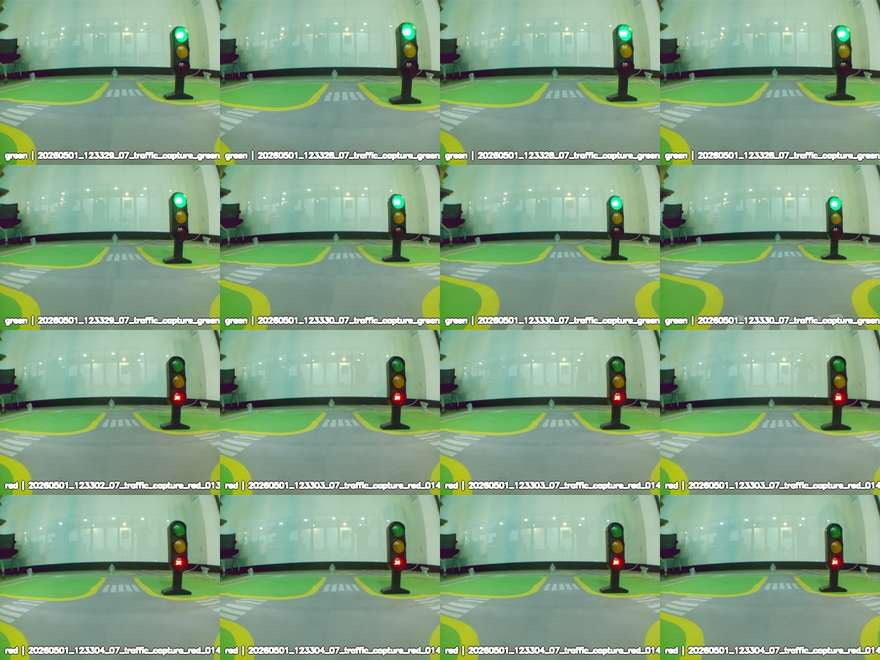

In [11]:
def make_original_grid(records, out_path, cols=4, tile_w=360, tile_h=270):
    tiles = []
    for rec in records:
        bgr = imread_bgr(rec["path"])
        vis = cv2.resize(bgr, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
        text = f'{rec["label"]} | {rec["filename"][:46]}'
        draw_label(vis, text, (8, tile_h-12), scale=0.42)
        tiles.append(vis)
    rows = math.ceil(len(tiles) / cols)
    blank = np.zeros((tile_h, tile_w, 3), dtype=np.uint8)
    grid_rows = []
    for r in range(rows):
        row_tiles = tiles[r*cols:(r+1)*cols]
        while len(row_tiles) < cols:
            row_tiles.append(blank.copy())
        grid_rows.append(np.concatenate(row_tiles, axis=1))
    grid = np.concatenate(grid_rows, axis=0)
    imwrite_bgr(out_path, grid)
    return out_path

out = OVERLAY_DIR / "traffic_manual_stress_original_grid.jpg"
make_original_grid(stress_df.to_dict("records"), out, cols=4)
print(out)
show_saved_image(out, width=1200)

## Manual stress HSV mask overlay

아래는 기존 HSV 후보들을 사용자가 지목한 stress sample에 그대로 씌운 결과다.

판단 포인트:

- green anchor 이미지에서 green 후보가 신호등을 놓치지 않는가?
- red anchor 이미지에서 red 후보가 신호등을 놓치지 않는가?
- 반대 색 후보가 같은 stress 이미지에서 얼마나 튀는가?
- 색만으로 부족한 부분이 contour/ROI로 해결 가능한 성격인가?

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_wide_s120_v120_on_green_true.jpg


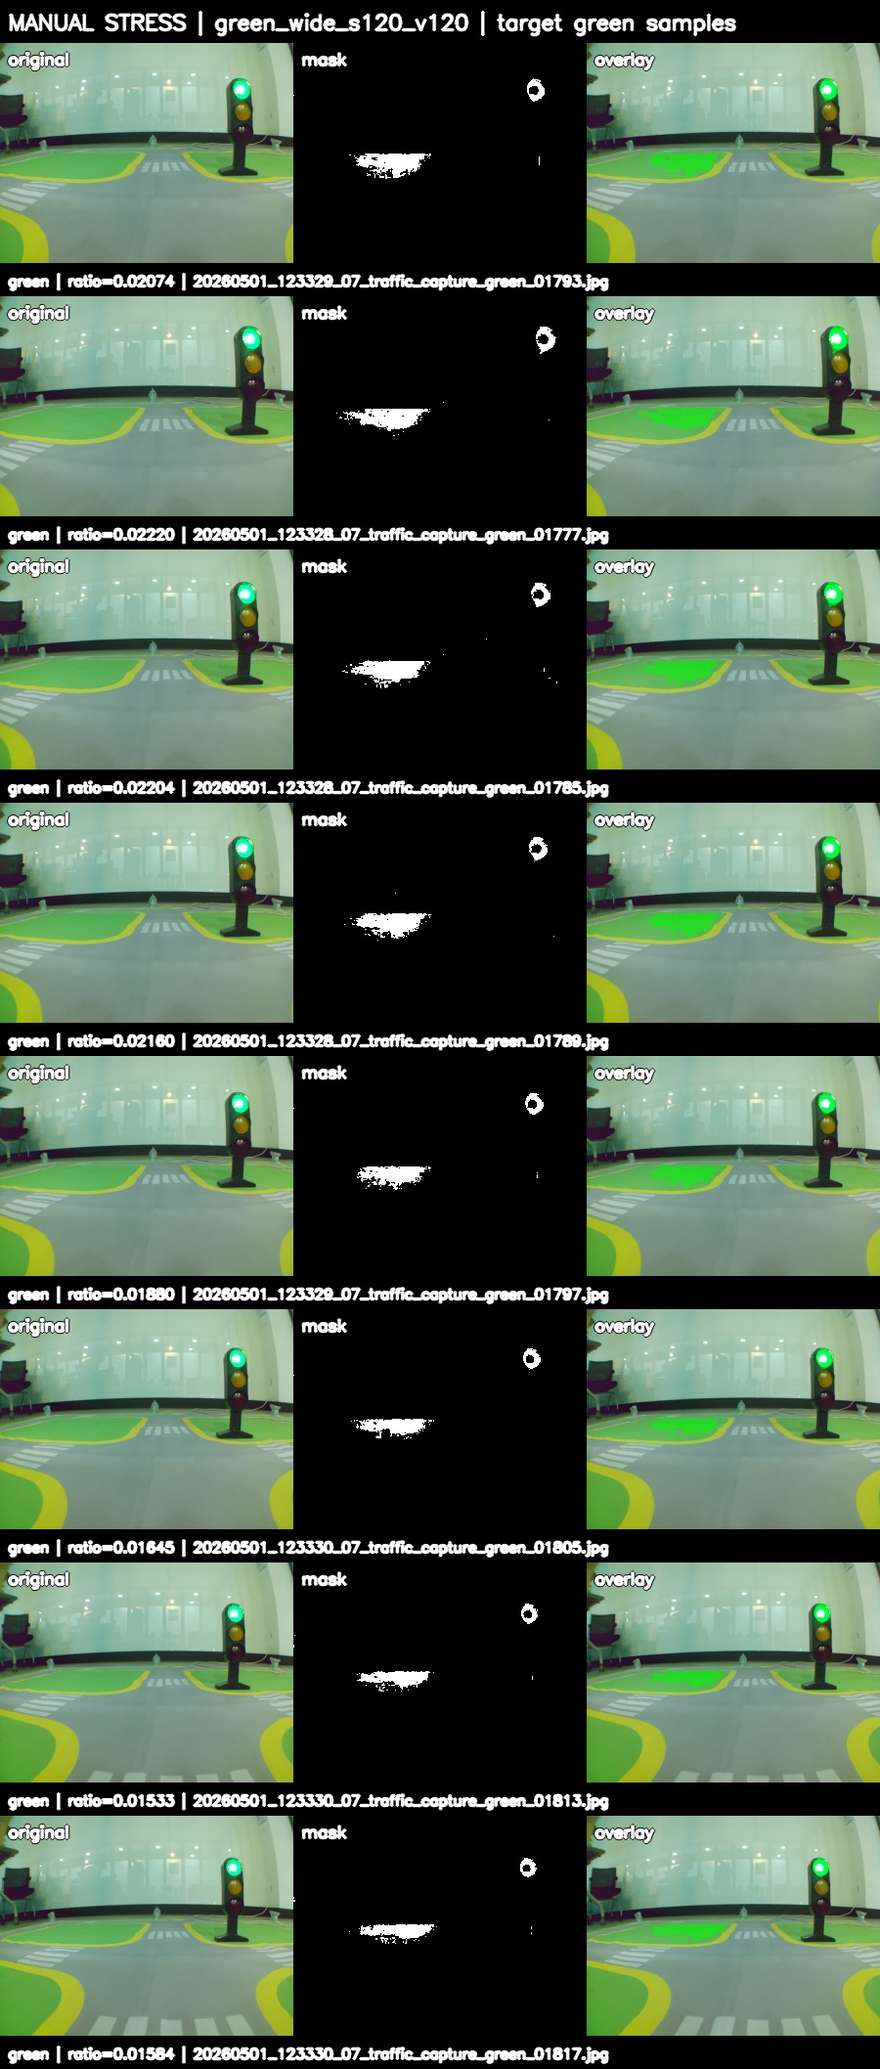

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_wide_s120_v120_on_red_cross.jpg


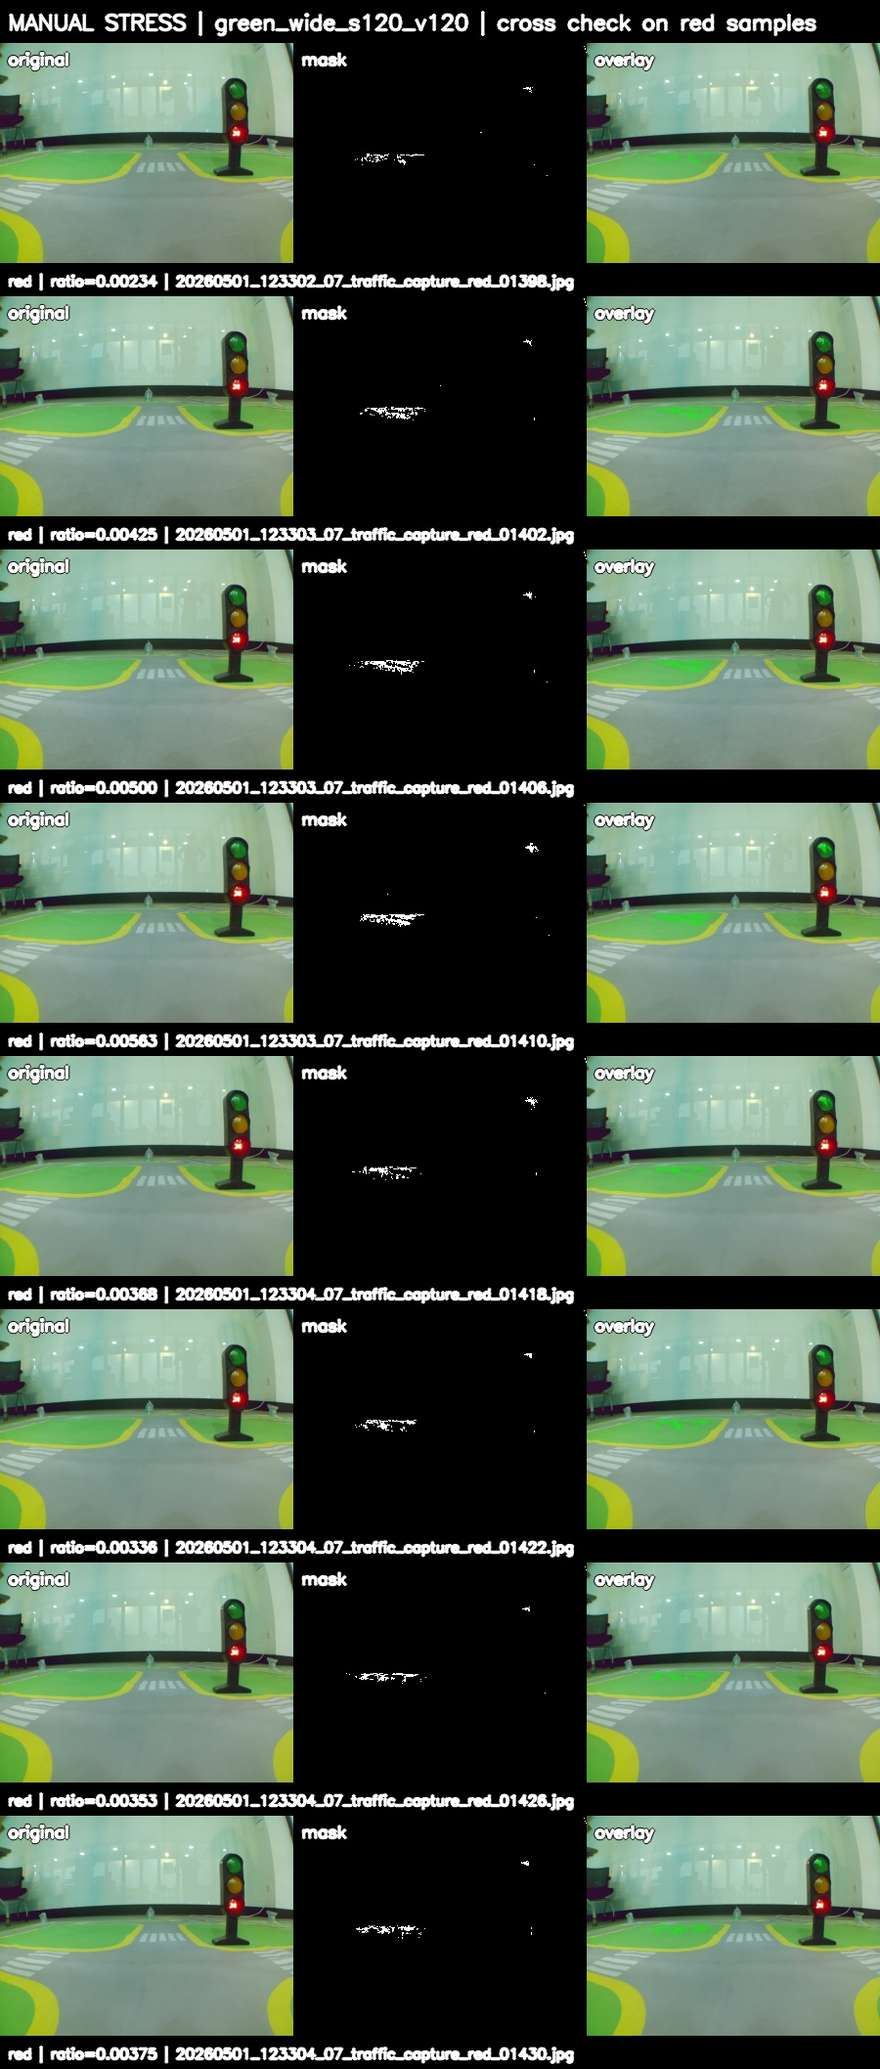

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_core_s140_v140_on_green_true.jpg


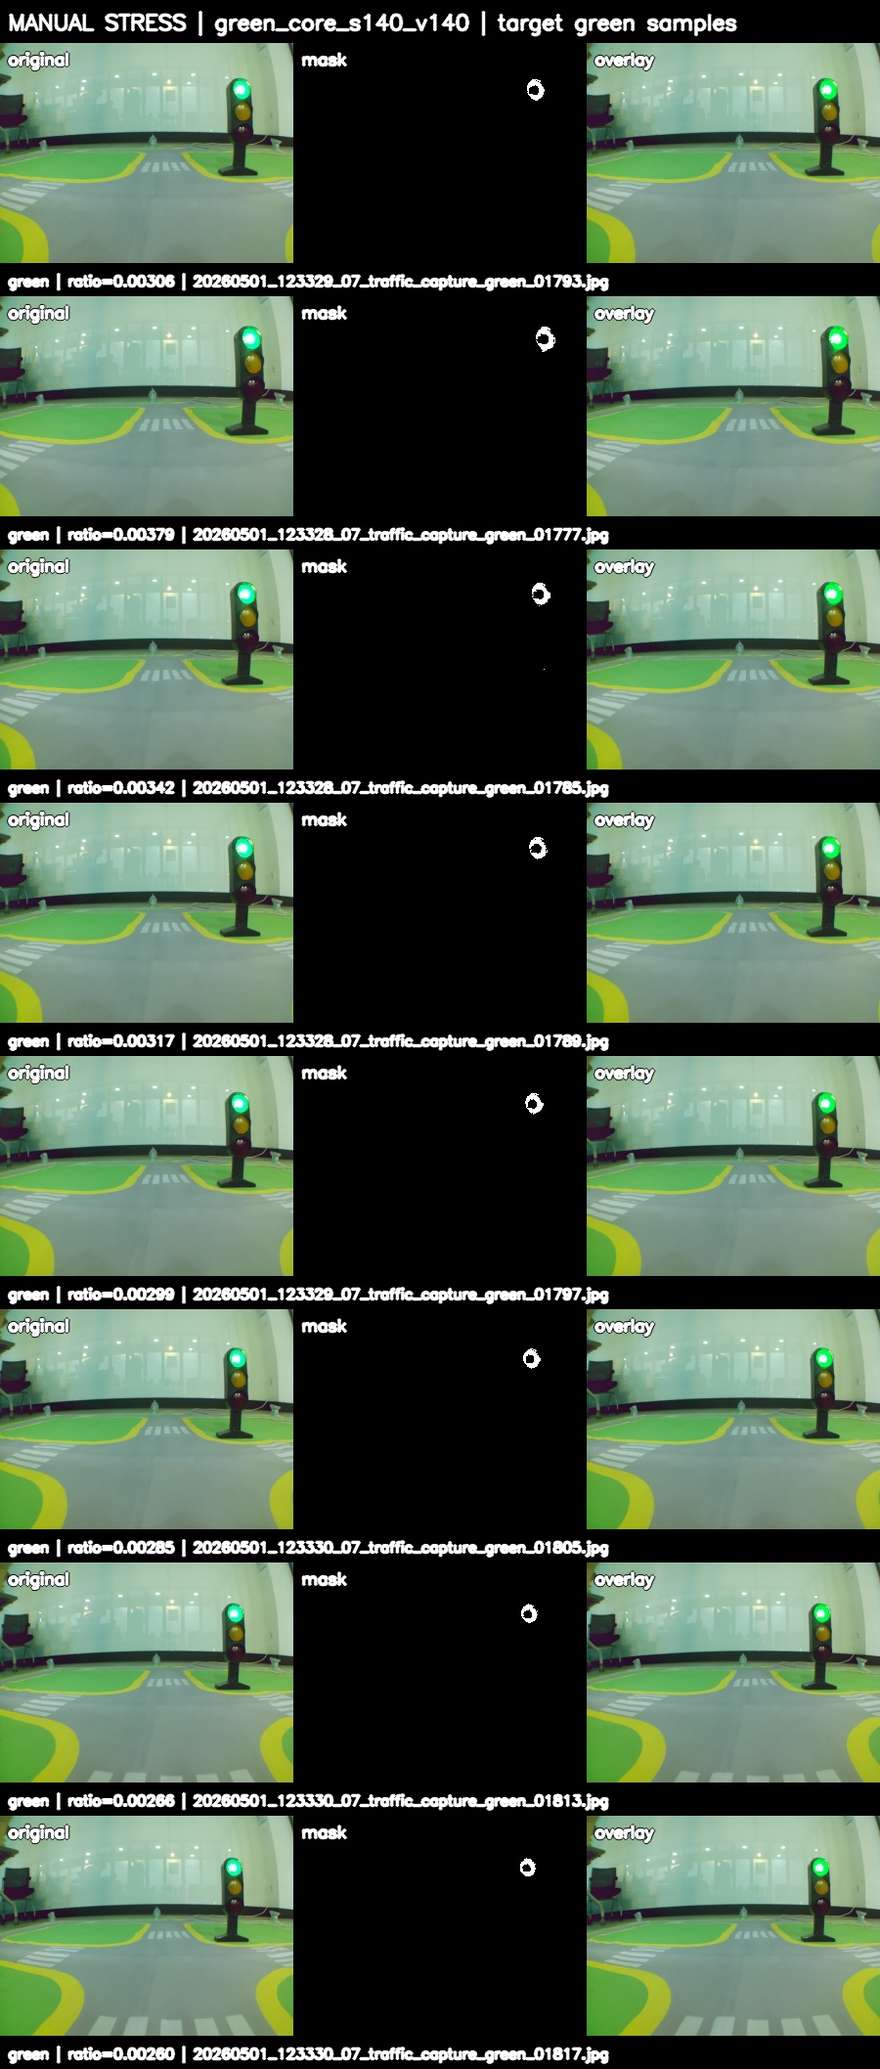

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_core_s140_v140_on_red_cross.jpg


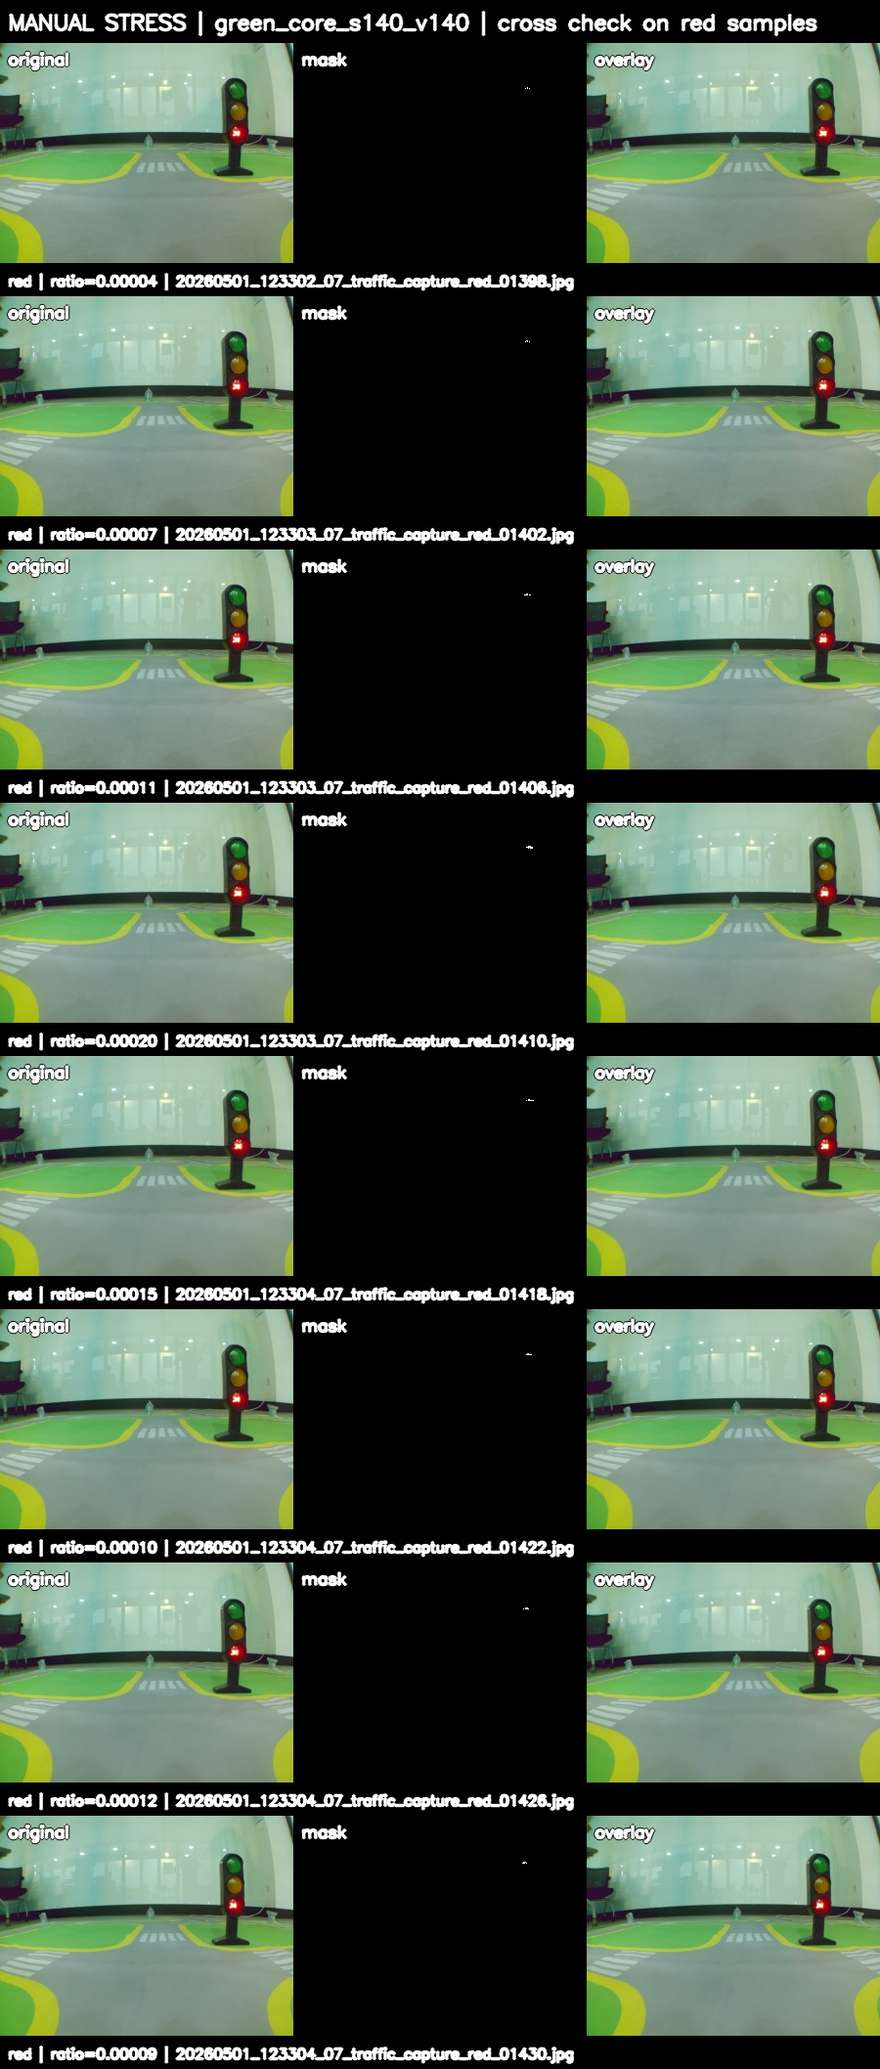

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_core_s160_v150_on_green_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_core_s160_v150_on_red_cross.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_tight_s170_v160_on_green_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_green_tight_s170_v160_on_red_cross.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_red_wide_s120_v120_on_red_true.jpg


...

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_red_core_s140_v140_on_green_cross.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_red_core_s160_v150_on_red_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_red_core_s160_v150_on_green_cross.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_red_tight_s180_v160_on_red_true.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\overlays\manual_stress_red_tight_s180_v160_on_green_cross.jpg


In [12]:
stress_green_records = stress_df[stress_df["label"] == "green"].to_dict("records")
stress_red_records = stress_df[stress_df["label"] == "red"].to_dict("records")

stress_sheet_paths = []
for cand in GREEN_CANDIDATES:
    out_true = OVERLAY_DIR / f'manual_stress_{cand["name"]}_on_green_true.jpg'
    out_cross = OVERLAY_DIR / f'manual_stress_{cand["name"]}_on_red_cross.jpg'
    make_candidate_sheet(cand, stress_green_records, out_true, f'MANUAL STRESS | {cand["name"]} | target green samples')
    make_candidate_sheet(cand, stress_red_records, out_cross, f'MANUAL STRESS | {cand["name"]} | cross check on red samples')
    stress_sheet_paths.extend([out_true, out_cross])
    print(out_true)
    show_saved_image(out_true, width=1100)
    print(out_cross)
    show_saved_image(out_cross, width=1100)

for cand in RED_CANDIDATES:
    out_true = OVERLAY_DIR / f'manual_stress_{cand["name"]}_on_red_true.jpg'
    out_cross = OVERLAY_DIR / f'manual_stress_{cand["name"]}_on_green_cross.jpg'
    make_candidate_sheet(cand, stress_red_records, out_true, f'MANUAL STRESS | {cand["name"]} | target red samples')
    make_candidate_sheet(cand, stress_green_records, out_cross, f'MANUAL STRESS | {cand["name"]} | cross check on green samples')
    stress_sheet_paths.extend([out_true, out_cross])
    print(out_true)
    show_saved_image(out_true, width=1100)
    print(out_cross)
    show_saved_image(out_cross, width=1100)

## Review notes 저장

이 노트북은 자동으로 결론을 내리지 않는다. 아래 notes는 사람이 overlay를 본 뒤 채워나갈 수 있는 체크리스트다.

In [13]:
notes = """# 01a Traffic HSV Mask Sweep Notes

## Purpose

Full-frame HSV mask sweep for traffic red/green lights.

No ROI, no contour, no morphology, no temporal voting, no contract.

## Candidate Tables

- `traffic_manual_stress_sample_records.csv`
- `traffic_manual_stress_pattern_debug.csv`
- `traffic_hsv_sweep_candidates.csv`
- `traffic_hsv_sweep_mask_ratios_per_image.csv`
- `traffic_hsv_sweep_mask_ratio_summary.csv`

## Overlay Outputs

Generated under `overlays/`:

- green candidates on green samples
- green candidates on red samples
- red candidates on red samples
- red candidates on green samples
- manual stress overlays for all candidates

## Human Review Questions

### Green

- Which green candidate catches the green lamp most consistently?
- Does the green mask also catch green floor too strongly?
- Is S/V tightening enough to reduce floor false positives?

### Red

- Which red candidate catches the red lamp most consistently?
- Does red mask catch red final-line-like floor objects too strongly?
- Does red wrap-around range need to be wide or tight?

## Next Step

After reviewing overlays, select 1-2 promising red candidates and 1-2 promising green candidates for the next traffic contour/mask sandbox.
"""
(NOTE_DIR / "01a_traffic_hsv_mask_sweep_notes.md").write_text(notes, encoding="utf-8")
print(NOTE_DIR / "01a_traffic_hsv_mask_sweep_notes.md")

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01a_traffic_hsv_mask_sweep_v1\notes\01a_traffic_hsv_mask_sweep_notes.md


## 다음 단계

이 노트북을 실행한 뒤에는 다음을 보고 판단한다.

1. green 후보 중 어떤 S/V 조합이 초록 신호를 가장 잘 잡는가?
2. red 후보 중 어떤 wrap-around 범위가 빨간 신호를 가장 잘 잡는가?
3. 색만으로는 어떤 false positive가 남는가?
4. 다음 contour 실험에서 무엇을 걸러야 하는가?

이 결과를 보고 나서 traffic용 contour/shape probe로 넘어간다. redline은 별도 02에서 따로 색 조합을 찾는다.